In [1]:
%matplotlib notebook
import torch
# from train import Trainer
from model import MVCNN
from build_nn import CNN, ResNet
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from dataset import PowderDataset
import numpy as np
from typing import Optional, Union
import matplotlib.pyplot as plt
from time import time
import torchvision.transforms as t
from battle_factory import ClassifierTrainer
from tqdm import tqdm

/home/gwb21218/miniconda3/envs/dm2/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pt_vibrant = {
    "blue" : "#0077BB",
    "cyan" : "#33BBEE",
    "teal" : "#009988",
    "orange" : "#EE7733",
    "red" : "#CC3311",
    "magenta" : "#EE3377",
    "grey" : "#BBBBBB"
}

In [ ]:
16*64*64

In [3]:
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, nef, avgpool_size=8):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, nef, kernel_size=11, padding=5),
#             nn.BatchNorm2d(nef),
            nn.ReLU(),
#             nn.Conv2d(nef, 2*nef, kernel_size=3, padding=1),
#             nn.BatchNorm2d(2*nef),
#             nn.ReLU(),
#             nn.MaxPool2d(2,2),
#             nn.Conv2d(nef, 2*nef, kernel_size=3, padding=1),
#             nn.BatchNorm2d(2*nef),
#             nn.ReLU(),
#             nn.Conv2d(4*nef, 4*nef, kernel_size=3, padding=1),
#             nn.BatchNorm2d(4*nef),
#             nn.ReLU(),
#             nn.MaxPool2d(2,2),
#             nn.Conv2d(2*nef, 4*nef, kernel_size=3, padding=1),
#             nn.BatchNorm2d(4*nef),
#             nn.ReLU(),
# #             nn.Conv2d(8*nef, 8*nef, kernel_size=3, padding=1),
# #             nn.BatchNorm2d(8*nef),
# #             nn.ReLU(),
#             nn.MaxPool2d(2,2)
        )
        
#         self.avg_pool = nn.AdaptiveAvgPool2d(avgpool_size)

#         self.features = nn.Sequential(
#             nn.Conv2d(patch_no, output_dim, kernel_size=5, stride=1, padding=2),
# #             nn.BatchNorm2d(output_dim),
#             nn.ReLU(),
# #             nn.Conv2d(output_dim, output_dim, kernel_size=3, stride=1, padding=1),
# #             nn.BatchNorm2d(output_dim),
# #             nn.ReLU()
#         )
        
        self.classifier = nn.Sequential(
            nn.Linear(64*64*nef, 10),
            nn.Tanh(),
            nn.Dropout(),
#             nn.Linear(300, 64),
#             nn.Tanh(),
#             nn.Dropout(),
            nn.Linear(10, num_classes)
        )
        
#         self.apply(self._init_weights)
        
#         for m in self.modules():
#             if not CNN:
# #                 nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
#                 nn.init.xavier_normal_(m.weight,gain=nn.init.calculate_gain("tanh"))
        
    def forward(self, inp):
#         out = self.conv(inp)
#         out, _ = torch.max(inp, dim=1)
        out = self.features(inp)
#         out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        
        return out
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, nonlinearity="tanh")
        elif isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, nonlinearity="tanh")

In [ ]:
cnn_dict = {
    "layers" : [3,4,6,3],
    "num_classes" : 3,
    "in_channels" : 1,
    "out_channels" : 512,
    "intermediate_channels" : [64,64,128,256],
    "kernel_sizes" : 3,
    "strides" : [2,2,2,2],
    "avgpool_size" : 8,
    "activation" : "leaky_relu"
}

In [4]:
# cnn = ResNet(**cnn_dict)
cnn = CNN(24,3,16)

In [ ]:
transforms = [t.RandomErasing(), t.RandomAdjustSharpness(0.5), t.RandomAffine(45), t.RandomAutocontrast(), t.RandomHorizontalFlip(), t.RandomVerticalFlip()]

In [ ]:
cnn

In [ ]:
mvcnn = MVCNN(cnn, num_classes=2)

In [ ]:
mvcnn

In [5]:
# optimi = optim.Adam(mvcnn.parameters(), lr=5e-4, weight_decay=1e-4)
# optimi = optim.Adam(cnn.parameters(), lr=5e-4, weight_decay=1e-4)
optimi = optim.SGD(cnn.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)
# optimi = optim.Adamax(cnn.parameters(), lr=1e-4, weight_decay=1e-4, betas=(0.9,0.9))

In [6]:
loss = nn.CrossEntropyLoss()

In [7]:
class MVCNNTrainer(ClassifierTrainer):
    def load_data(self) -> None:
        f = np.load(self.data_pth)
        
        self.train_in = f["train_in"]
        self.train_out = f["train_out"]
        self.val_in = f["val_in"]
        self.val_out = f["val_out"]
        
    def train(self, train_loader: torch.utils.data.DataLoader) -> float:
        self.model.train()

        batch_losses = []
        total, correct = 0., 0.
        for j, (images, labels) in enumerate(tqdm(train_loader)):
            images, labels = images.float().to(self.device), labels.long().to(self.device)
#             images, labels = images.float().unsqueeze(2).to(self.device), labels.long().to(self.device)

            self.optimiser.zero_grad()
            output = self.model(images)
            loss = self.loss_fn(output, labels)
            loss.backward()
            self.optimiser.step()
            
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum()

            batch_losses.append(loss.item())

        if self.scheduler:
            self.scheduler.step()

        return torch.mean(torch.tensor(batch_losses)), float((correct / total) * 100)

    def validation(self, val_loader: torch.utils.data.DataLoader) -> float:
        self.model.eval()

        total, correct = 0., 0.
        with torch.no_grad():
            batch_losses = []
            for images, labels in val_loader:
                images, labels = images.float().to(self.device), labels.long().to(self.device)
#                 images, labels = images.float().unsqueeze(2).to(self.device), labels.long().to(self.device)
                output = self.model(images)
                loss = self.loss_fn(output, labels)
                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum()
                batch_losses.append(loss.item())

        return torch.mean(torch.tensor(batch_losses)), float((correct / total) * 100)
        
    def cool_beauty(self, load: bool = False, load_pth: Optional[str] = None, transform: Union[nn.Module, nn.Sequential, t.Compose, None] = None) -> None:
        """
        This class method trains the network with the interactive plotting environment.
        """
    
        if load:
            print("=> a model is being loaded.")
            self.load_checkpoint(load_pth)

        # dataset and data loader creation
        train_dataset = PowderDataset(torch.from_numpy(self.train_in), torch.from_numpy(self.train_out), transform=transform)
        val_dataset = PowderDataset(torch.from_numpy(self.val_in), torch.from_numpy(self.val_out), transform=transform)
        # val_dataset = PowderDataset(torch.from_numpy(self.val_in), torch.from_numpy(self.val_out))

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=True)

        #initialisation of the plotting environment
        fig = plt.figure(figsize=(6,6))
        train_ax = fig.add_subplot(2,1,1)
        val_ax = train_ax.twinx()
        # train_ax.set_yscale("log")
        train_ax.set_ylabel("Training Loss", color=pt_vibrant["cyan"])
        train_ax.tick_params(axis="x", labelbottom=False)
#         train_ax.set_xlabel("Number of Epochs")
        val_ax.set_ylabel("Validation Loss", color=pt_vibrant["magenta"])
        train_ax_perc = fig.add_subplot(2,1,2)
        val_ax_perc = train_ax_perc.twinx()
        train_ax_perc.set_ylabel("Training Percentage [%]", color=pt_vibrant["cyan"])
        train_ax_perc.set_xlabel("Number of Epochs")
        val_ax_perc.set_ylabel("Validation Percentage [%]", color=pt_vibrant["magenta"])
        fig.show()
        fig.canvas.draw()

        #define lists to store the different losses in
        train_losses, val_losses, train_perc, val_perc = [], [], [], []

        #do the training and validation
        t_init = time()
        for n in range(self.total_epochs):
            if n != 0:
                self.current_epoch += 1
            if n == 0 and load:
                self.current_epoch += 1

            tl, tp = self.train(train_loader=train_loader)
            train_losses.append(tl.item())
            train_perc.append(tp)

            vl, vp = self.validation(val_loader=val_loader)
            val_losses.append(vl.item())
            val_perc.append(vp)
            t_now = round(time() - t_init, 3)

        #save the model
            self.train_losses = train_losses
            self.val_losses = val_losses
            self.train_perc = train_perc
            self.val_perc = val_perc

#             if self.scheduler:
#                 self.checkpoint(add_info={"scheduler_state_dict" : self.scheduler.state_dict()})
#             else:
#                 self.checkpoint()
#             self.save_checkpoint()

        #plot the results
            fig.suptitle(f"Time elapsed {t_now}s after epoch {self.current_epoch}")
            train_ax.set_ylabel("Training Loss", color=pt_vibrant["cyan"])
            train_ax.tick_params(axis="x", labelbottom=False)
            train_ax_perc.set_xlabel("Number of Epochs")
            val_ax.set_ylabel("Validation Loss", color=pt_vibrant["magenta"])
            train_ax_perc.set_ylabel("Training Percentage [%]", color=pt_vibrant["cyan"])
            val_ax_perc.set_ylabel("Validation Percentage [%]", color=pt_vibrant["magenta"])
            train_ax.semilogy(train_losses, color=pt_vibrant["cyan"], marker="o")
            val_ax.semilogy(val_losses, color=pt_vibrant["magenta"], marker="o")
            train_ax_perc.plot(train_perc, color=pt_vibrant["cyan"], marker="o")
            val_ax_perc.plot(val_perc, color=pt_vibrant["magenta"], marker="o")
            fig.canvas.draw()

In [ ]:
sched = optim.lr_scheduler.CosineAnnealingLR(optimi, T_max=15, eta_min=1e-5)
# sched = optim.lr_scheduler.ReduceLROnPlateau(optimi, patience=4, threshold=1e-3)
# sched = optim.lr_scheduler.StepLR(optimi, 20)
# sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimi, T_0=20, eta_min=1e-5, verbose=True)

In [8]:
trainer = MVCNNTrainer(cnn,optimi,loss,50,16,"/mnt/d/John/multi_pow/training_data_15_64_aug_3.npz")
# trainer = MVCNNTrainer(cnn,optimi,loss,50,16,"training_data_15_64.npz")
# trainer = MVCNNTrainer(cnn,optimi,loss,50,16,"/mnt/d/John/multi_pow/training_data_15_64_aug_4_bin_1.npz",scheduler=None)
# trainer = Trainer(mvcnn,optimi,loss,data_pth="D:/gwb21218/segmented_dataset/",save_dir="D:/gwb21218/multi_pow/")
# trainer = Trainer(mvcnn,optimi,loss,data_pth="segmented_dataset/",save_dir="C:/Users/gwb21218/multi_pow/")

In [9]:
%%time
trainer.load_data()

CPU times: user 8.15 s, sys: 415 ms, total: 8.56 s
Wall time: 13.1 s


In [10]:
trainer.model.load_state_dict(torch.load("classifier.pth"))

<All keys matched successfully>

In [ ]:
trainer.train_in.shape

In [ ]:
trainer.val_out

In [ ]:
np.savez_compressed("training_data.npz", train_in=trainer.train_in, train_out=trainer.train_out, val_in=trainer.val_in, val_out=trainer.val_out)

In [ ]:
data = np.load("training_data_15_64.npz")

In [ ]:
data["train_in"].shape

In [ ]:
%%time
trainer.train_in = data["train_in"]/255
trainer.train_out = data["train_out"]
trainer.val_in = data["val_in"]/255
trainer.val_out = data["val_out"]

In [ ]:
trainer.train_in[0]

In [ ]:
torch.cuda.empty_cache()

In [ ]:
trainer.val_out.shape[0] * 0.4520

In [ ]:
trainer.model.features[0].weight.grad

In [ ]:
trainer.cool_beauty()

In [ ]:
trainer.model.module.features[0]

In [ ]:
trainer.model.module.classifier[0].weight

In [ ]:
trainer.val_in.shape[0]*0.56

In [ ]:
trainer.train_perc[-1]

In [ ]:
trainer.val_perc[-1]

In [21]:
from sklearn.metrics import confusion_matrix

In [92]:
trainer.train_in[59*30].shape

(24, 64, 64)

In [95]:
with torch.no_grad():
    y_pred = trainer.model(torch.from_numpy(trainer.val_in).float().to(trainer.device))
    _, y_pred = torch.max(y_pred.data,1)
    y_pred = y_pred.cpu().numpy().astype(np.uint8)

In [11]:
with torch.no_grad():
    prob_dist = trainer.model(torch.from_numpy(trainer.train_in[59*30]).float().unsqueeze(0).to(trainer.device))
    prob_dist = prob_dist.cpu().numpy()
    prob_dist = nn.functional.softmax(torch.from_numpy(prob_dist)).numpy().squeeze()

/tmp/ipykernel_69/3433683520.py:4: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prob_dist = nn.functional.softmax(torch.from_numpy(prob_dist)).numpy().squeeze()


In [108]:
prob_dist

array([0.22864485, 0.34081593, 0.43053922], dtype=float32)

<IPython.core.display.Javascript object>


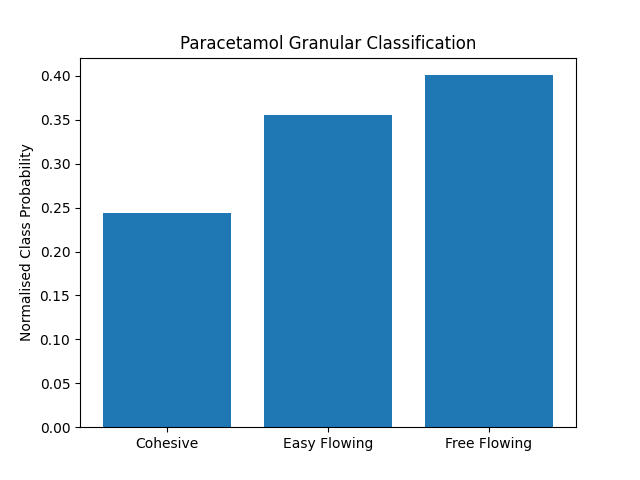

In [12]:
plt.figure()
plt.bar(["Cohesive", "Easy Flowing", "Free Flowing"], prob_dist)
plt.ylabel("Normalised Class Probability")
plt.title("Paracetamol Granular Classification")
plt.savefig("poster_plots/paracetamol_prob_dist.png", dpi=300, pad_inches=0.1)

In [23]:
y_pred

array([2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1,
       2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2,
       1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 1, 2, 1,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2,

In [48]:
(((y_pred == trainer.val_out).sum())/trainer.val_out.shape[0])*100

46.22222222222222

In [24]:
trainer.val_out

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [28]:
cm = confusion_matrix(trainer.val_out, y_pred, normalize="true")

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

In [42]:
rc_context_dict = {
    "savefig.bbox" : "tight",
    "font.family" : "serif",
    "figure.figsize" : (10,6),
    "font.size" : 14,
    "font.serif" : "New Century Schoolbook"
}

In [43]:
plt.rcParams.update(rc_context_dict)

<IPython.core.display.Javascript object>


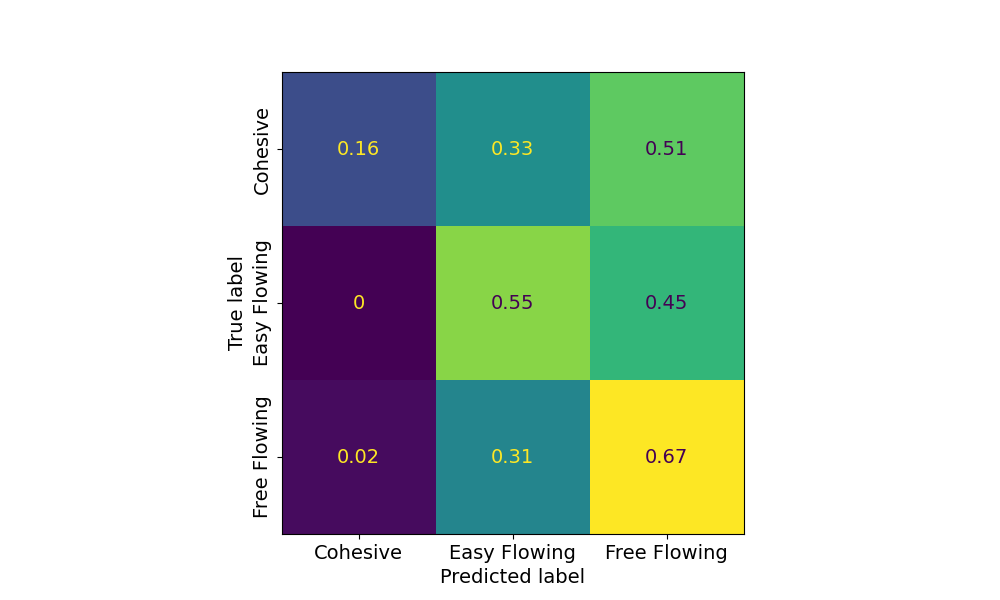

In [90]:
# fig = plt.figure()
cmd = ConfusionMatrixDisplay(cm).plot(colorbar=False)
cmd.ax_.set_xticklabels(["Cohesive", "Easy Flowing", "Free Flowing"])
cmd.ax_.set_yticklabels(["Cohesive", "Easy Flowing", "Free Flowing"], rotation=90, va="center")
plt.savefig("poster_plots/cm.png", dpi=300, pad_inches=0.1, transparent=True)

<IPython.core.display.Javascript object>


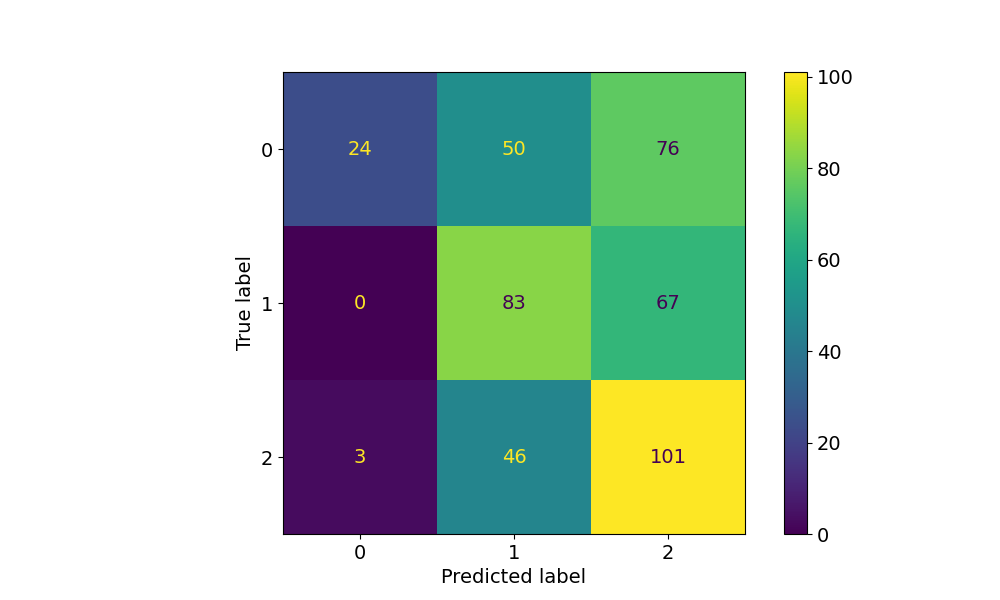

In [64]:
cmd.figure_

<IPython.core.display.Javascript object>


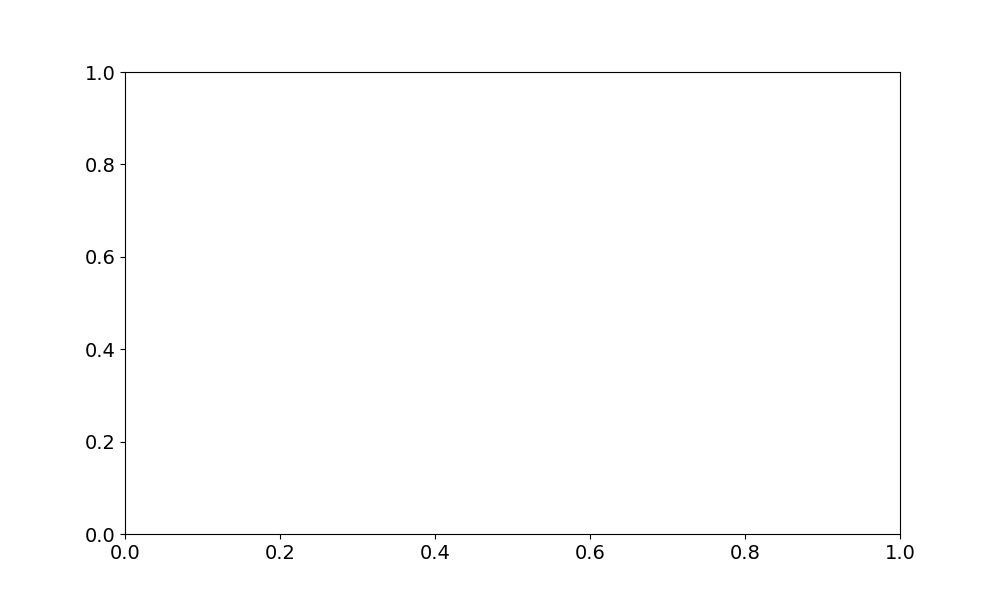

ValueError: not enough values to unpack (expected 2, got 0)

In [62]:
plt.figure()
plt.pcolormesh(cmd.im_)

<IPython.core.display.Javascript object>


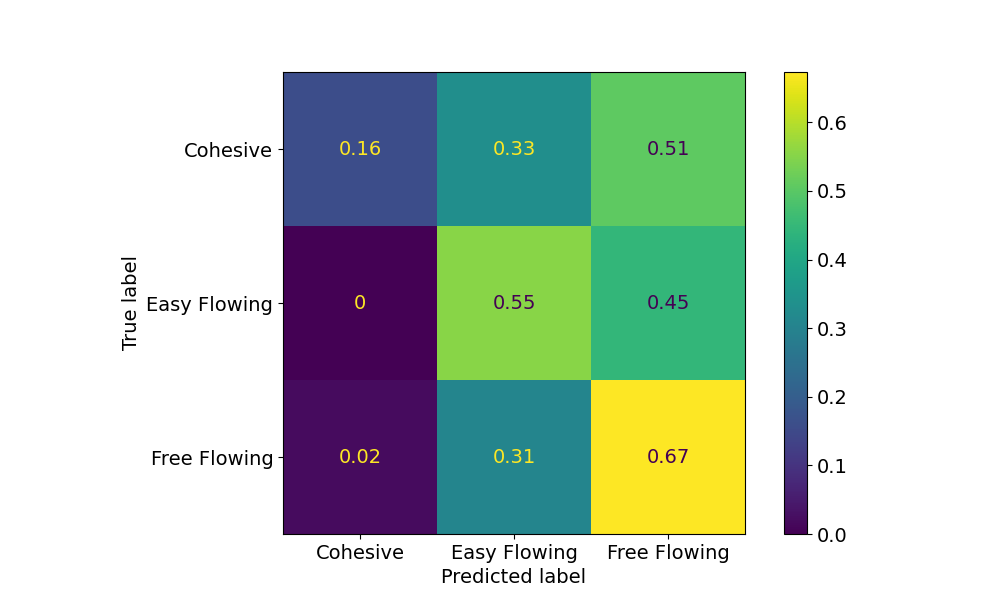

In [44]:
cmd.plot()

In [ ]:
8*8*128

In [ ]:
torch.save(trainer.model.state_dict(), "classifier2.pth")

In [ ]:
trainer.train_losses

In [ ]:
trainer.val_losses

In [ ]:
trainer.train(DataLoader(TensorDataset(torch.from_numpy(trainer.train_in), torch.from_numpy(trainer.train_out))))

In [ ]:
val_loader = DataLoader(PowderDataset(torch.from_numpy(trainer.val_in), torch.from_numpy(trainer.val_out)), batch_size=1, shuffle=False)

In [ ]:
image, label = iter(val_loader).next()

In [ ]:
image.shape

In [ ]:
label

In [ ]:
trainer.validation(val_loader)

In [ ]:
writer = SummaryWriter("runs/powder_data_3")

In [ ]:
writer.add_graph(mvcnn.cuda(),torch.randn(1,24,1,1024,1024).cuda())

In [ ]:
writer.close()

In [ ]:
torch.distributed.is_available()

# Autoencoder

In [ ]:
class Lambda(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, x):
        return self.func(x)

In [ ]:
class AE(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, stride=2, kernel_size=7,padding=3),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64,128, stride=2, kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
#             Lambda(lambda x: x.view(x.size(0), -1)),
#             nn.Linear(128*64*64,1000)
            nn.Conv2d(128, 1, stride=1, kernel_size=1)
        )
        
        self.decoder = nn.Sequential(
            nn.Conv2d(1, 128, stride=1, kernel_size=1),
#             nn.Linear(1000,128*64*64),
#             Lambda(lambda x: x.view(x.size(0), 128, 64, 64)),
            nn.ConvTranspose2d(128,64,stride=2,kernel_size=3,padding=1,output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, in_channels, stride=2, kernel_size=3,padding=1,output_padding=1),
            nn.LeakyReLU(),
        )
        
    def forward(self, x):
        h = self.encoder(x)
        out = self.decoder(h)
        
        return out

In [ ]:
ae = AE(1).to("cuda:0")

In [ ]:
ae

In [ ]:
ae.to("cuda:0")

In [ ]:
data = np.load("training_data_15.npz")

In [ ]:
train_in, train_out = data["train_in"], data["train_in"]
val_in, val_out = data["val_in"], data["val_in"]

In [ ]:
train_in, train_out = train_in.reshape(-1,1024,1024), train_out.reshape(-1,1024,1024)
val_in, val_out = val_in.reshape(-1,1024,1024), val_out.reshape(-1,1024,1024)

In [ ]:
train_in.shape

In [ ]:
ae(torch.from_numpy(train_in[0]/255).unsqueeze(0).unsqueeze(0).float()).shape

In [ ]:
criterion = nn.MSELoss()
optimi = optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-6)
sched = optim.lr_scheduler.StepLR(optimi, 50, verbose=True)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_dataset = TensorDataset(torch.from_numpy(train_in/255).unsqueeze(1), torch.from_numpy(train_out/255).unsqueeze(1))
val_dataset = TensorDataset(torch.from_numpy(val_in/255).unsqueeze(1), torch.from_numpy(val_out/255).unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [ ]:
from tqdm import tqdm_notebook

In [ ]:
for n in range(200):
    batch_losses = []
    for j, (images, labels) in enumerate(tqdm_notebook(train_loader)):
        images, labels = images.float().to("cuda:0"), labels.float().to("cuda:0")

        optimi.zero_grad()
        output = ae(images)
        loss = criterion(output, labels)
        loss.backward()
        optimi.step()

        batch_losses.append(loss.item())

    train_loss = torch.mean(torch.tensor(batch_losses))
        
    batch_val_losses = []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.float().to("cuda:0"), labels.float().to("cuda:0")
            output = ae(images)
            loss = criterion(output, labels)
            
            batch_val_losses.append(loss.item())
            
    val_loss = torch.mean(torch.tensor(batch_val_losses))
    
    sched.step()
        
    print(f"For epoch {n}, train loss = {train_loss}, val loss = {val_loss}")

In [ ]:
torch.save(ae.state_dict(), "trained_ae.pth")

In [ ]:
ae.state_dict()

In [ ]:
ae.load_state_dict(torch.load("trained_ae.pth"))

In [ ]:
with torch.no_grad():
    out = ae(torch.from_numpy(val_in[-1]/255).unsqueeze(0).unsqueeze(0).float().cuda()).squeeze().cpu().numpy()

In [ ]:
out.shape

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(val_in[-1], cmap="Greys_r")
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(out, cmap="Greys_r")

In [ ]:
with torch.no_grad():
    out = ae.encoder(torch.from_numpy(val_in[60]/255).unsqueeze(0).unsqueeze(0).float().cuda()).squeeze().cpu().numpy()

In [ ]:
out.shape

In [ ]:
from matplotlib.colors import PowerNorm

In [ ]:
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(out, cmap="Greys_r", norm=PowerNorm(1.2))

ax2 = fig.add_subplot(1,2,2)
ax2.imshow(val_in[60], cmap="Greys_r")